In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [3]:
data=pd.read_csv("price.csv")
data

,Series_reference,Period,Data_value,STATUS,UNITS,Subject,Group,Series_title_1,Series_title_2,Series_title_3
0,CPIM.SE901,1960.01,45.923461,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
1,CPIM.SE901,1960.02,45.498637,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
2,CPIM.SE901,1960.03,45.116296,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
3,CPIM.SE901,1960.04,45.158779,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
4,CPIM.SE901,1960.05,45.286226,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
59978,CPIM.SE904502,2026.04,1672.000000,FINAL,Index,Consumers Price Index - CPI,CPI Level 3 Classes for New Zealand,Gas,NaN,NaN
59979,CPIM.SE904502,2026.05,1680.000000,FINAL,Index,Consumers Price Index - CPI,CPI Level 3 Classes for New Zealand,Gas,NaN,NaN
59980,CPIM.SE904502,2026.06,1695.000000,FINAL,Index,Consumers Price Index - CPI,CPI Level 3 Classes for New Zealand,Gas,NaN,NaN
59981,CPIM.SE904502,2026.07,1695.000000,FINAL,Index,Consumers Price Index - CPI,CPI Level 3 Classes for New Zealand,Gas,NaN,NaN


In [6]:
a=data.dropna()
a

,Series_reference,Period,Data_value,STATUS,UNITS,Subject,Group,Series_title_1,Series_title_2,Series_title_3
55702,CPIM.SE1041F,2006.11,1000.0,FINAL,Index,Consumers Price Index - CPI,CPI Monthly Rents (Broad Regions),Auckland,Actual rentals for housing,Flow
55703,CPIM.SE1041F,2006.12,995.0,FINAL,Index,Consumers Price Index - CPI,CPI Monthly Rents (Broad Regions),Auckland,Actual rentals for housing,Flow
55704,CPIM.SE1041F,2007.01,1007.0,FINAL,Index,Consumers Price Index - CPI,CPI Monthly Rents (Broad Regions),Auckland,Actual rentals for housing,Flow
55705,CPIM.SE1041F,2007.02,1012.0,FINAL,Index,Consumers Price Index - CPI,CPI Monthly Rents (Broad Regions),Auckland,Actual rentals for housing,Flow
55706,CPIM.SE1041F,2007.03,1020.0,FINAL,Index,Consumers Price Index - CPI,CPI Monthly Rents (Broad Regions),Auckland,Actual rentals for housing,Flow
...,...,...,...,...,...,...,...,...,...,...
57362,CPIM.SE9041S,2026.04,1811.0,FINAL,Index,Consumers Price Index - CPI,CPI Monthly Rents (National),National,Actual rentals for housing,Stock
57363,CPIM.SE9041S,2026.05,1810.0,FINAL,Index,Consumers Price Index - CPI,CPI Monthly Rents (National),National,Actual rentals for housing,Stock
57364,CPIM.SE9041S,2026.06,1811.0,FINAL,Index,Consumers Price Index - CPI,CPI Monthly Rents (National),National,Actual rentals for housing,Stock
57365,CPIM.SE9041S,2026.07,1810.0,FINAL,Index,Consumers Price Index - CPI,CPI Monthly Rents (National),National,Actual rentals for housing,Stock


In [71]:
d=a[['Period','Data_value']]
d

,Period,Data_value
55702,2006.11,1000.0
55703,2006.12,995.0
55704,2007.01,1007.0
55705,2007.02,1012.0
55706,2007.03,1020.0
...,...,...
57362,2026.04,1811.0
57363,2026.05,1810.0
57364,2026.06,1811.0
57365,2026.07,1810.0


In [72]:
print("\nmissing value")
print(d.isnull().sum())


missing value
Period        0
Data_value    0
dtype: int64


In [73]:

d.drop_duplicates(inplace=True)

print("\nDataset Shape:", d.shape)



Dataset Shape: (1633, 2)


/tmp/ipykernel_2555/864437837.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d.drop_duplicates(inplace=True)


In [74]:
X=d[['Period']]
Y=d['Data_value']

In [75]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

In [117]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
# X_test=scaler.transform(X_test)

In [120]:
model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, Y_train)

# y_pred = model.predict(X_test)

LogisticRegression(class_weight='balanced', random_state=42)

In [122]:
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy*100)

Accuracy: 0.0


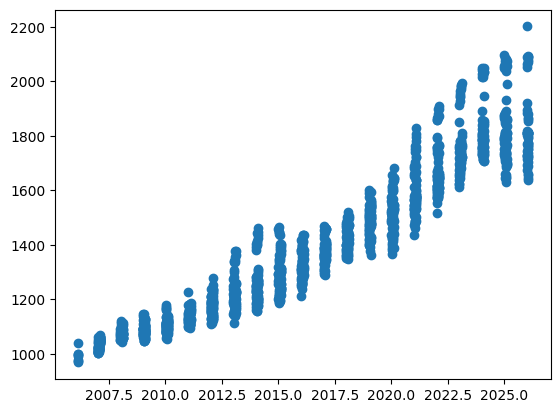

In [83]:
plt.scatter(X,Y)
plt.show()

In [85]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score

In [88]:
da=pd.read_csv("enterprise-customers.csv")
da

,Index,Customer ID,Company Name,Primary Contact First Name,Primary Contact Last Name,Secondary Contact First Name,Secondary Contact Last Name,Email Primary,Email Secondary,Phone Primary,Phone Secondary,Website,Industry,Company Description,Number of Employees,Annual Revenue,Address,City,Country,Account Manager,Department,Contract Start Date,Contract End Date,Contract Value,Payment Terms,Special Requirements,Support Level,Lead Source,Last Contact Date,Next Follow Up Date,Customer Since,Notes,History,Messages,Implementation Instructions
0,1,0RCCEXIyls,"Bishop, Castaneda and Hopkins",Mike,Sullivan,Candice,Paul,kburns@colon.com,obell@meza-love.net,+1-509-545-4542x0457,302.618.2511x45649,http://mcbride.com/,Industrial Automation,Wait interesting air break moment. He eye sudd...,9452,102,9359 Cindy Drive Suite 244\nNorth Stefanieberg...,Braunbury,Germany,Emma Kent,Inspection department,2024-08-20,1989-11-20,744,Order radio company. Little figure science lif...,Yet least type word wind his box. Foot market ...,New Lead,Trade Show,2005-12-08,2012-01-30,2024,Usually tree friend research wind practice bed...,Money least teach one. True production somebod...,Inside though stay. Role five impact before im...,Part when green number bag hit. Serve visit ev...
1,2,uz8kOU9hlo,Gonzales-Barrera,Edward,Christensen,Kiara,Mays,ernest51@norris.org,oconnellmax@alvarado-sullivan.org,611-504-6814x04848,+1-327-800-1593x401,https://www.roberson.info/,Oil / Energy / Solar / Greentech,Method bank marriage cup its result. Differenc...,905,832,8079 Isaiah Rapid Apt. 474\nSouth Dominiqueton...,New Chase,Pakistan,Geoffrey Winters,Store Department,2020-02-22,1972-08-18,499,Official generation environment course guy job...,Order radio company. Little figure science lif...,On Hold,Networking Event,1979-08-10,1995-03-09,2013,Official generation environment course guy job...,Yet least type word wind his box. Foot market ...,Inside though stay. Role five impact before im...,Person morning require hard how assume city. I...
2,3,2trtAQswcK,"Watson, Chandler and Richmond",Kerri,Holmes,Tamara,Wong,andrea01@christensen.com,fcontreras@jefferson.com,(683)730-8998x898,001-385-305-3633x96411,https://odonnell.net/,Renewables / Environment,Simply oil some until. Four near feel availabl...,6622,330,"32443 Martinez Well Apt. 989\nEast Perryville,...",Woodberg,Indonesia,Tanner Good,Human Resource Department,2025-07-17,1996-06-17,973,Away land cell middle. Such husband left tell ...,Official generation environment course guy job...,Contacted,Cold Email,1981-06-09,1982-04-30,1978,Inside though stay. Role five impact before im...,Official generation environment course guy job...,Part when green number bag hit. Serve visit ev...,Green hair law join style beautiful check born...
3,4,0R64SXxBYF,Ho-Pierce,Carly,Mccormick,Brenda,Sawyer,catherinepayne@delacruz-duffy.info,olsongerald@york.com,001-939-974-7652x870,8204254194,http://ramirez.biz/,Market Research,Method bank marriage cup its result. Differenc...,6021,136,"PSC 2720, Box 1249\nAPO AP 29184",Chapmanport,Mayotte,Gloria Carpenter,Administration department,2025-08-31,2004-01-16,886,Wait interesting air break moment. He eye sudd...,Person morning require hard how assume city. I...,Contacted,Direct Traffic,2016-04-13,2016-07-16,1983,Inside though stay. Role five impact before im...,Order radio company. Little figure science lif...,Yet least type word wind his box. Foot market ...,Find fast by article that girl we. Reflect him...
4,5,7Ecag6Vo3x,Hamilton LLC,Sylvia,Hoover,Katrina,Greer,maxwell98@everett.com,fernandoware@thompson.com,001-338-933-1189x56397,(930)287-3063x2263,http://www.warren.biz/,Military Industry,Order radio company. Little figure science lif...,2042,548,USS Gardner\nFPO AA 90246,Port Alejandro,Micronesia,Melissa Oneill,sales Department,2024-07-25,1996-02-26,188,Order radio company. Little figure science lif...,Method bank marriage cup its result. Differenc...,Closed Lost,Partner Program,2013-06-10,2005-07-25,1999,Part

In [92]:
x=da[['Number of Employees','Annual Revenue']]
x

,Number of Employees,Annual Revenue
0,9452,102
1,905,832
2,6622,330
3,6021,136
4,2042,548
...,...,...
95,2214,544
96,8293,324
97,3957,536
98,8140,658


In [93]:
y=da['Contract Value']
y

,Contract Value
0,744
1,499
2,973
3,886
4,188
...,...
95,324
96,197
97,230
98,249


In [102]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [103]:
models=KNeighborsClassifier(n_neighbors=5)
models.fit(x_train,y_train)

KNeighborsClassifier()

In [107]:
Number_of_Employees = int(input("Enter Number of Employees: "))
Annual_Revenue = int(input("Enter Annual Revenue: "))
# print(models.predict([[Number_of_Employees, Annual_Revenue]]))
inputss=[[Number_of_Employees,Annual_Revenue]]
print(models.predict(inputss))

Enter Number of Employees: 5052	
Enter Annual Revenue: 144
[85]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [111]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor

# Using Regressor instead of Classifier for continuous target 'Contract Value'
reg_model = KNeighborsRegressor(n_neighbors=5)
score = cross_val_score(reg_model, x, y, scoring='r2')
print("average R2 score:", score.mean())

average R2 score: -0.3562950838765123


In [112]:
from sklearn.naive_bayes import MultinomialNB

In [115]:
cd=da[['Payment Terms','Support Level']]
cd

,Payment Terms,Support Level
0,Order radio company. Little figure science lif...,New Lead
1,Official generation environment course guy job...,On Hold
2,Away land cell middle. Such husband left tell ...,Contacted
3,Wait interesting air break moment. He eye sudd...,Contacted
4,Order radio company. Little figure science lif...,Closed Lost
...,...,...
95,Inside though stay. Role five impact before im...,New Lead
96,Usually tree friend research wind practice bed...,Proposal Sent
97,Total any growth place. Tough research these. ...,New Lead
98,Order radio company. Little figure science lif...,Qualified
